In [ ]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = '/home/alonso/Documents/ccRCC/data/tcga_kirc_voi_f/img/'
mask_dir = '/home/alonso/Documents/ccRCC/data/tcga_kirc_voi_f/msk/'

# Get all .npy files from base directory
base_files = list(Path(base_dir).rglob('*.npy'))

print(f'Found {len(base_files)} files in base directory.')

# Create dictionary of paired files {relative_path: (base_path, mask_path)}
paired_files = {}

for base_path in base_files:
    relative_path = str(base_path.relative_to(base_dir))
    mask_path = Path(mask_dir) / relative_path

    # Only add if corresponding mask exists
    if mask_path.exists():
        # Use filename without .npy as key
        key = base_path.stem  # Gets filename without extension
        paired_files[key] = (str(base_path), str(mask_path))

print(f'Found {len(paired_files)} matching pairs.')

# Keep backward compatibility with existing code
folder_path = base_dir
filenames = [str(Path(base_dir) / f"{k}.npy") for k in paired_files.keys()]
mask_folder = mask_dir



Found 319 files in base directory.
Found 319 matching pairs.


In [13]:
count_files = 0

Random file selected: TCGA-B0-4839_AD_00_fallback_case_00083_R
-1011.0 1253.0 -12.330122 117.60782
Shape: (128, 128, 128)
0
319


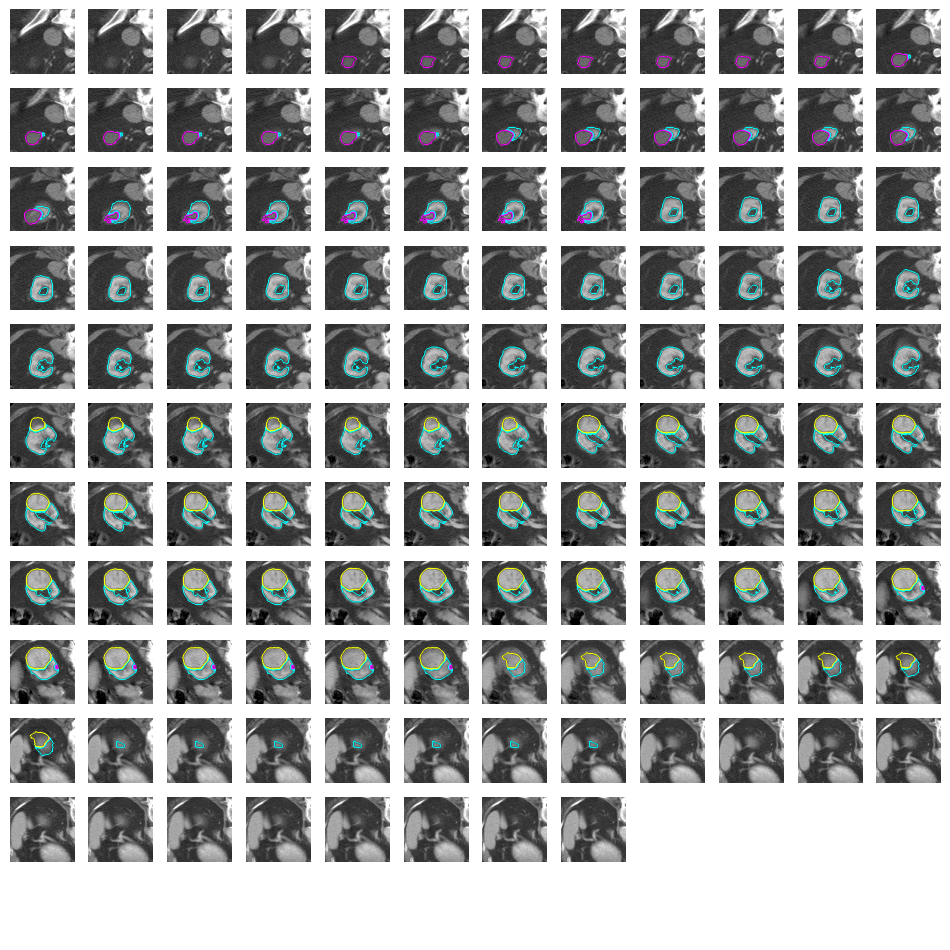

In [14]:
import math
from matplotlib.colors import ListedColormap
from scipy import ndimage

# Select the first patient name and create a counter to explor on by one
patient = os.path.basename(filenames[count_files])[:-4]

img_file = paired_files[patient][0]
mask_file = paired_files[patient][1]
print("Random file selected:", patient)

# Load the .npy file
img_data = np.load(os.path.join(folder_path, img_file))
msk_data = np.load(os.path.join(mask_folder, mask_file))
print(np.min(img_data), np.max(img_data), np.mean(img_data), np.std(img_data))

# Show the shape
print("Shape:", img_data.shape)
print(count_files)
print(len(filenames))

# Plot img slices with mask boundaries only (kidney=cyan, tumor=yellow, cyst=magenta)
# Plot all three views: axial, sagittal, coronal

n_slices = img_data.shape[2]
grid_size = math.ceil(math.sqrt(n_slices))

# Function to extract boundaries from mask with increased thickness
def get_boundaries(mask_slice, iterations=3):
    boundaries = np.zeros_like(mask_slice, dtype=bool)
    for label in [1, 2, 3]:  # kidney, tumor, cyst
        mask_label = (mask_slice == label)
        if mask_label.any():
            eroded = ndimage.binary_erosion(mask_label, iterations=iterations)
            boundary = mask_label & ~eroded
            boundaries |= boundary
    return boundaries

# Sagittal view (along axis 0)
n_slices_sag = img_data.shape[0]
grid_size_sag = math.ceil(math.sqrt(n_slices_sag))
fig, axes = plt.subplots(grid_size_sag, grid_size_sag, figsize=(10, 10), dpi=96)
axes_flat = axes.flatten()
for idx in range(grid_size_sag * grid_size_sag):
    if idx < n_slices_sag:
        axes_flat[idx].imshow(img_data[idx,:,:], cmap='gray', vmin=-200, vmax=300)
        boundaries = get_boundaries(msk_data[idx,:,:])
        mask_slice = msk_data[idx,:,:]
        boundary_img = np.zeros((*mask_slice.shape, 4))
        boundary_img[boundaries & (mask_slice == 1)] = [0, 1, 1, 1]
        boundary_img[boundaries & (mask_slice == 2)] = [1, 1, 0, 1]
        boundary_img[boundaries & (mask_slice == 3)] = [1, 0, 1, 1]
        axes_flat[idx].imshow(boundary_img)
        axes_flat[idx].axis('off')
    else:
        axes_flat[idx].axis('off')
plt.tight_layout()
plt.show()

# # Axial view (original)
# fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10), dpi=96)
# axes_flat = axes.flatten()
# for idx in range(grid_size * grid_size):
#     if idx < n_slices:
#         axes_flat[idx].imshow(img_data[:,:,idx], cmap='gray', vmin=-150, vmax=300)
#         boundaries = get_boundaries(msk_data[:,:,idx])
#         mask_slice = msk_data[:,:,idx]
#         boundary_img = np.zeros((*mask_slice.shape, 4))
#         boundary_img[boundaries & (mask_slice == 1)] = [0, 1, 1, 1]  # cyan for kidney
#         boundary_img[boundaries & (mask_slice == 2)] = [1, 1, 0, 1]  # yellow for tumor
#         boundary_img[boundaries & (mask_slice == 3)] = [1, 0, 1, 1]  # magenta for cyst
#         axes_flat[idx].imshow(boundary_img)
#         axes_flat[idx].axis('off')
#     else:
#         axes_flat[idx].axis('off')
# plt.tight_layout()
# plt.show()

# # Coronal view (along axis 1)
# n_slices_cor = img_data.shape[1]
# grid_size_cor = math.ceil(math.sqrt(n_slices_cor))
# fig, axes = plt.subplots(grid_size_cor, grid_size_cor, figsize=(10, 10), dpi=96)
# axes_flat = axes.flatten()
# for idx in range(grid_size_cor * grid_size_cor):
#     if idx < n_slices_cor:
#         axes_flat[idx].imshow(img_data[:,idx,:], cmap='gray', vmin=-150, vmax=300)
#         boundaries = get_boundaries(msk_data[:,idx,:])
#         mask_slice = msk_data[:,idx,:]
#         boundary_img = np.zeros((*mask_slice.shape, 4))
#         boundary_img[boundaries & (mask_slice == 1)] = [0, 1, 1, 1]
#         boundary_img[boundaries & (mask_slice == 2)] = [1, 1, 0, 1]
#         boundary_img[boundaries & (mask_slice == 3)] = [1, 0, 1, 1]
#         axes_flat[idx].imshow(boundary_img)
#         axes_flat[idx].axis('off')
#     else:
#         axes_flat[idx].axis('off')
# plt.tight_layout()
# plt.show()

count_files += 1


In [ ]:
import numpy as np
import re

# Compute volumes of tumor (mask=2) for all paired files
files_with_tumor = {}

voxel_spacing_mm = [1.0, 1.0, 1.0]  # [x, y, z] in mm
voxel_volume_mm3 = np.prod(voxel_spacing_mm)
voxel_volume_cm3 = voxel_volume_mm3 / 1000  # Convert mm³ to cm³

# Dictionary to store case-level information
case_summary = {}

for item in paired_files:
    # Load mask
    mask = np.load(item['mask_path'])
    
    # Extract case ID using regex
    case_id_match = re.search(r'case_(\d{5})', item['case_name'])
    if case_id_match:
        case_id = case_id_match.group(1)
    else:
        case_id = 'unknown'
    
    # Determine kidney side from case name
    kidney_side = 'Right' if item['case_name'].endswith('_R') else 'Left'
    
    # Count voxels where mask == 2 (tumor)
    tumor_voxels = np.sum(mask == 2)
    
    # Initialize case summary if not exists
    if case_id not in case_summary:
        case_summary[case_id] = {'Left': 'no tumor', 'Right': 'no tumor'}
    
    # Only include if tumor is present
    if tumor_voxels > 0:
        volume = tumor_voxels * voxel_volume_cm3

        # compute bbox and compute the expected shape in 3D if we crop to bbox
        coords = np.argwhere(mask == 2)
        x_min, y_min, z_min = coords.min(axis=0)
        x_max, y_max, z_max = coords.max(axis=0)
        bbox = [x_min, x_max, y_min, y_max, z_min, z_max]

        # show the shape of final expected cropped volume
        expected_shape = (x_max - x_min + 1, y_max - y_min + 1, z_max - z_min + 1)
        
        # Store metadata in dictionary
        files_with_tumor[item['case_name']] = {
            'case_id': case_id,
            'kidney_side': kidney_side,
            'tumor_volume_cm3': volume,
            'tumor_voxels': int(tumor_voxels),
            'bbox': bbox,
            'expected_shape': expected_shape
        }
        
        # Update case summary
        case_summary[case_id][kidney_side] = 'tumor'

print(f"Patients with tumor: {len(files_with_tumor)}")
print(f"\nCase summary (case_id: {{Left: status, Right: status}}):")
for case_id, status in sorted(case_summary.items()):
    print(f"  case_{case_id}: {status}")

In [ ]:
import shutil
import json

# Create output directory for tumor cases
output_dir = Path("ukb2025_1_voi_tumor/A/")
output_dir.mkdir(exist_ok=True, parents=True)

# Copy files with tumors to new directory
for case_name in files_with_tumor.keys():
    # Find the source file
    source_file = image_dir / f"{case_name}.npy"
    
    # Check if file exists in subdirectories
    if not source_file.exists():
        # Search recursively
        matches = list(image_dir.rglob(f"{case_name}.npy"))
        if matches:
            source_file = matches[0]
        else:
            print(f"Warning: Could not find {case_name}.npy")
            continue
    
    # Copy the file
    dest_file = output_dir / f"{case_name}.npy"
    shutil.copy(source_file, dest_file)

# Save metadata as JSON - convert numpy types to native Python types
metadata_to_save = {}
for case_name, data in files_with_tumor.items():
    metadata_to_save[case_name] = {
        'kidney_side': data['kidney_side'],
        'tumor_volume_cm3': float(data['tumor_volume_cm3']),
        'tumor_voxels': int(data['tumor_voxels']),
        'bbox': [int(x) for x in data['bbox']],
        'expected_shape': tuple(int(x) for x in data['expected_shape'])
    }

metadata_file = output_dir / "metadata.json"
with open(metadata_file, 'w') as f:
    json.dump(metadata_to_save, f, indent=2)
print(f"Copied {len(files_with_tumor)} files with tumors to {output_dir}")

In [3]:
import os
from pathlib import Path

# Discover pairs of CT images and segmentation masks

image_dir = Path("../tcga_kirc_v3_f/")
mask_dir = Path("../tcga_kirc_v3_f_masks/")

# Find all CT images ending with _0000.nii.gz (recursively in all subfolders)
image_files = sorted(list(image_dir.rglob("*npy")))
print(f"{len(image_files)} CT images found")

# Create pairs by matching case names
pairs = []
for img_path in image_files:
    # Extract case name by removing _0000.nii.gz suffix
    case_name = img_path.stem
    
    # Look for corresponding mask file (recursively in mask_dir)
    mask_matches = list(mask_dir.rglob(f"{case_name}.npy"))
    
    if mask_matches:
        mask_path = mask_matches[0]  # Take first match
        pairs.append({
            'case_name': case_name,
            'image_path': str(img_path),
            'mask_path': str(mask_path)
        })
    else:
        print(f"Warning: No mask found for {case_name}")

print(f"\nFound {len(pairs)} image-mask pairs")
print("\nFirst 5 pairs:")
for pair in pairs[:5]:
    print(f"  - {pair['case_name']}")
    print(f"    Image: {pair['image_path']}")
    print(f"    Mask:  {pair['mask_path']}")

320 CT images found

Found 320 image-mask pairs

First 5 pairs:
  - TCGA-B0-5399_A_00_fallback_case_00113_L
    Image: ../tcga_kirc_v3_f/A/TCGA-B0-5399_A_00_fallback_case_00113_L.npy
    Mask:  ../tcga_kirc_v3_f_masks/A/TCGA-B0-5399_A_00_fallback_case_00113_L.npy
  - TCGA-B0-5399_A_00_fallback_case_00113_R
    Image: ../tcga_kirc_v3_f/A/TCGA-B0-5399_A_00_fallback_case_00113_R.npy
    Mask:  ../tcga_kirc_v3_f_masks/A/TCGA-B0-5399_A_00_fallback_case_00113_R.npy
  - TCGA-B0-5712_A_00_fallback_case_00132_L
    Image: ../tcga_kirc_v3_f/A/TCGA-B0-5712_A_00_fallback_case_00132_L.npy
    Mask:  ../tcga_kirc_v3_f_masks/A/TCGA-B0-5712_A_00_fallback_case_00132_L.npy
  - TCGA-B0-5712_A_00_fallback_case_00132_R
    Image: ../tcga_kirc_v3_f/A/TCGA-B0-5712_A_00_fallback_case_00132_R.npy
    Mask:  ../tcga_kirc_v3_f_masks/A/TCGA-B0-5712_A_00_fallback_case_00132_R.npy
  - TCGA-B8-5158_A_00_art_case_00151_L
    Image: ../tcga_kirc_v3_f/A/TCGA-B8-5158_A_00_art_case_00151_L.npy
    Mask:  ../tcga_kirc_v3_

In [ ]:
# img_file_to_delete = paired_files[patient][0]
# mask_file_to_delete = paired_files[patient][1]

# # Delete image file
# if os.path.exists(img_file_to_delete):
#     os.remove(img_file_to_delete)
#     print(f"Deleted image file: {img_file_to_delete}")
# else:
#     print(f"Image file not found: {img_file_to_delete}")
# # Delete mask file
# if os.path.exists(mask_file_to_delete):
#     os.remove(mask_file_to_delete)
#     print(f"Deleted mask file: {mask_file_to_delete}")
# else:
#     print(f"Mask file not found: {mask_file_to_delete}")

Deleted image file: ../tcga_kirc_voi_2_new_filtered/A/TCGA-BP-4766_A_00_nc_case_00197_L.npy
Deleted mask file: ../tcga_kirc_voi_2_new_filtered_masks/A/TCGA-BP-4766_A_00_nc_case_00197_L.npy


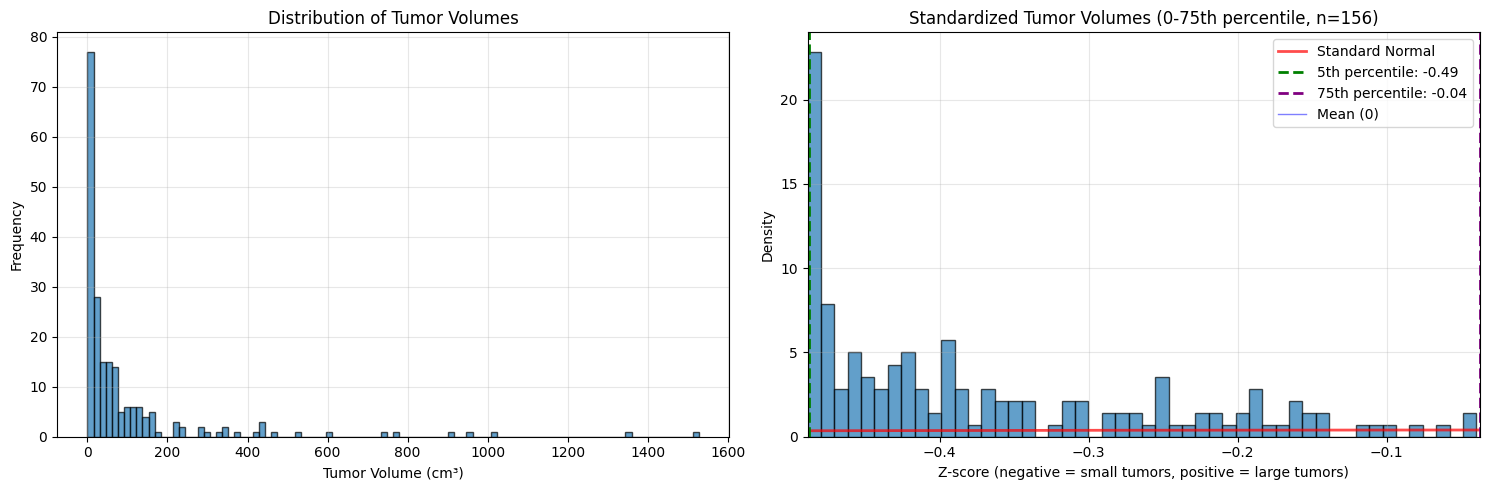


5th percentile Z-score: -0.49 (volume: 0.16 cm³)
75th percentile Z-score: -0.04 (volume: 94.84 cm³)
95th percentile Z-score: 1.59 (volume: 436.68 cm³)

Data points in 0-75th percentile: 156 / 208 (75.0%)

Tumor Volume Statistics and Percentile Distribution

Basic Statistics:
  Total patients with tumor: 208
  Total patients without tumor: 112
  Min tumor volume: 0.01 cm³
  Max tumor volume: 1527.97 cm³
  Mean tumor volume: 102.69 cm³
  Median tumor volume: 29.76 cm³
  Std deviation: 210.17 cm³

--------------------------------------------------------------------------------
Percentile   Volume (cm³)    Z-score      Patient Count   Cumulative %   
--------------------------------------------------------------------------------
5th          0.16            -0.49        11              5.3            
10th          0.95            -0.48        21              10.1           
25th          7.00            -0.46        52              25.0           
50th          29.76           -0.35    

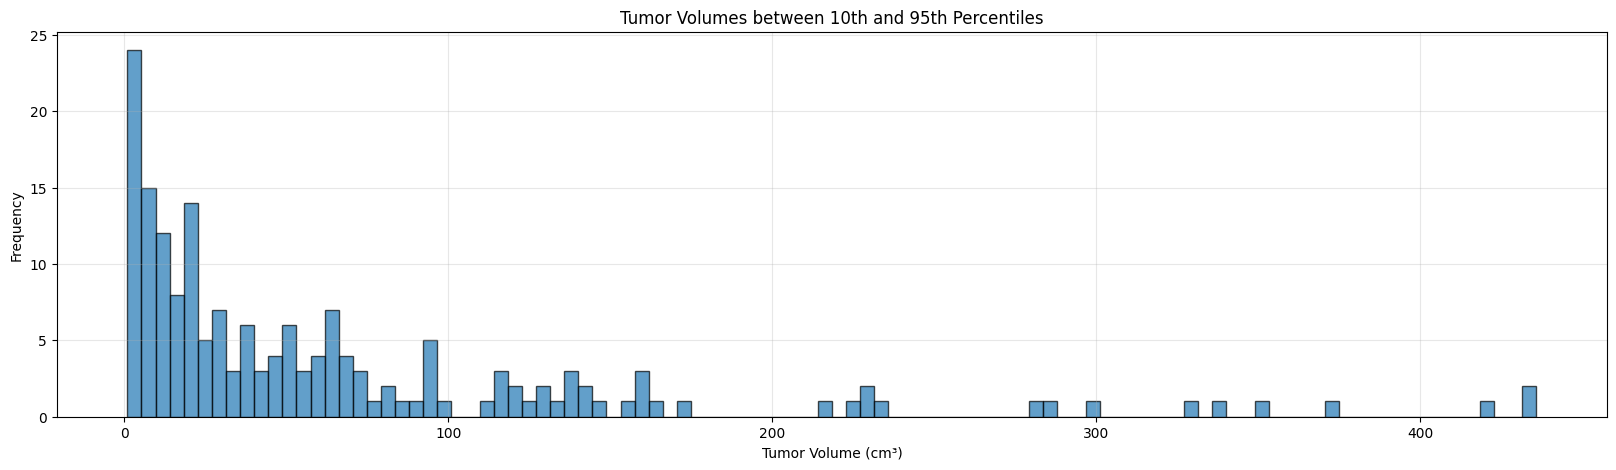

Unique groups (excluding NG and D): {'AB', 'BD', 'AD', 'AC', 'A', 'C', 'B', 'BC'}


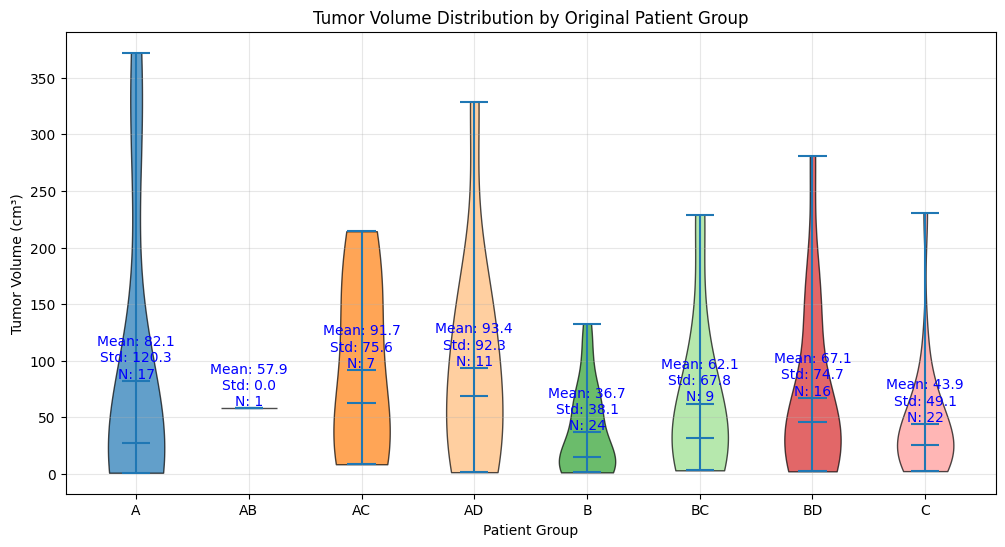

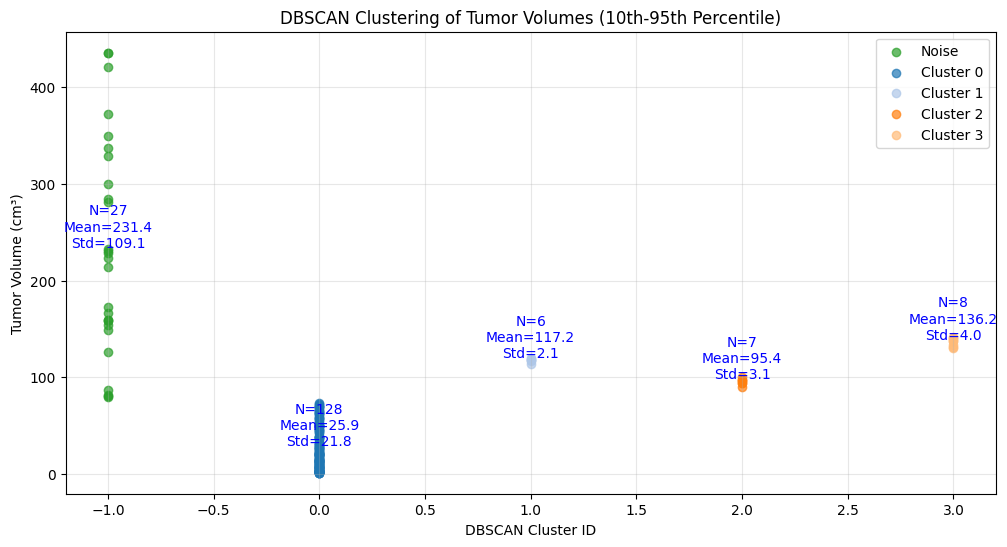

In [2]:
from typing import Counter
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import ranksums
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
# Compute volumes of tumor (mask=2) for all paired files
tumor_volumes = []
patients_with_tumor = {}
max_bbox = [0, 0, 0, 0, 0, 0]  # [x_min, x_max, y_min, y_max, z_min, z_max]
# Voxel spacing in mm (adjust these values based on your actual data)
# Common TCGA KIRC spacing is around 0.78 x 0.78 x 3.0 mm
voxel_spacing_mm = [1.0, 1.0, 1.0]  # [x, y, z] in mm
voxel_volume_mm3 = np.prod(voxel_spacing_mm)
voxel_volume_cm3 = voxel_volume_mm3 / 1000  # Convert mm³ to cm³

for item in pairs:
    # Load mask
    mask = np.load(item['mask_path'])
    
    # Count voxels where mask == 2 (tumor)
    tumor_voxels = np.sum(mask == 2)
    
    # Only include if tumor is present
    if tumor_voxels > 0:
        volume = tumor_voxels * voxel_volume_cm3
        tumor_volumes.append(volume)
        
        # Determine kidney side from case name
        case_name = item['case_name']
        kidney_side = 'Right' if case_name.endswith('_R') else 'Left'
        
        # compute bbox and compute the expected shape in 3D if we crop to bbox
        coords = np.argwhere(mask == 2)
        x_min, y_min, z_min = coords.min(axis=0)
        x_max, y_max, z_max = coords.max(axis=0)
        bbox = [x_min, x_max, y_min, y_max, z_min, z_max]
        
        # Update max_bbox
        max_bbox[0] = min(max_bbox[0], x_min)
        max_bbox[1] = max(max_bbox[1], x_max)
        max_bbox[2] = min(max_bbox[2], y_min)
        max_bbox[3] = max(max_bbox[3], y_max)
        max_bbox[4] = min(max_bbox[4], z_min)
        max_bbox[5] = max(max_bbox[5], z_max)
        
        # show the shape of final expected cropped volume
        expected_shape = (x_max - x_min + 1, y_max - y_min + 1, z_max - z_min + 1)
        
        # Store metadata in dictionary
        patients_with_tumor[case_name] = {
            'kidney_side': kidney_side,
            'tumor_volume_cm3': volume,
            'tumor_voxels': int(tumor_voxels),
            'bbox': bbox,
            'expected_shape': expected_shape
        }
        
# Convert to NumPy array for numerical operations
tumor_volumes = np.array(tumor_volumes)

# Compute percentiles
percentiles = [5, 10, 25, 50, 75, 95, 100]
percentile_values = np.percentile(tumor_volumes, percentiles)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of tumor volumes
axes[0].hist(tumor_volumes, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Tumor Volume (cm³)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Tumor Volumes')
axes[0].grid(True, alpha=0.3)

# Standardize the data (Z-score normalization)
z_scores = (tumor_volumes - tumor_volumes.mean()) / tumor_volumes.std()

# Calculate percentiles
percentile_5 = np.percentile(z_scores, 5)
percentile_75 = np.percentile(z_scores, 75)
percentile_95 = np.percentile(z_scores, 95)

# Filter z_scores to 0-75th percentile range for visualization
z_scores_filtered = z_scores[z_scores <= percentile_75]

# Plot histogram with density for filtered data
counts, bins, patches = axes[1].hist(z_scores_filtered, bins=50, edgecolor='black', alpha=0.7, density=True)

# Overlay Gaussian curve over the displayed range
x_range_nonzero = np.linspace(z_scores.min(), percentile_75, 1000)
gaussian = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_range_nonzero**2)
axes[1].plot(x_range_nonzero, gaussian, 'r-', linewidth=2, label='Standard Normal', alpha=0.7)

# Add percentile lines
axes[1].axvline(percentile_5, color='green', linestyle='--', linewidth=2, label=f'5th percentile: {percentile_5:.2f}')
axes[1].axvline(percentile_75, color='purple', linestyle='--', linewidth=2, label=f'75th percentile: {percentile_75:.2f}')
axes[1].axvline(0, color='blue', linestyle='-', linewidth=1, alpha=0.5, label='Mean (0)')

# Set x-axis to show 0-75th percentile range
axes[1].set_xlim(z_scores.min(), percentile_75)

axes[1].set_xlabel('Z-score (negative = small tumors, positive = large tumors)')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Standardized Tumor Volumes (0-75th percentile, n={len(z_scores_filtered)})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print percentile information
print(f"\n5th percentile Z-score: {percentile_5:.2f} (volume: {percentile_5 * tumor_volumes.std() + tumor_volumes.mean():.2f} cm³)")
print(f"75th percentile Z-score: {percentile_75:.2f} (volume: {percentile_75 * tumor_volumes.std() + tumor_volumes.mean():.2f} cm³)")
print(f"95th percentile Z-score: {percentile_95:.2f} (volume: {percentile_95 * tumor_volumes.std() + tumor_volumes.mean():.2f} cm³)")
print(f"\nData points in 0-75th percentile: {len(z_scores_filtered)} / {len(z_scores)} ({100*len(z_scores_filtered)/len(z_scores):.1f}%)")

# Create comprehensive percentiles table
print("\n" + "="*80)
print("Tumor Volume Statistics and Percentile Distribution")
print("="*80)

# Basic statistics
print(f"\nBasic Statistics:")
print(f"  Total patients with tumor: {len(tumor_volumes)}")
print(f"  Total patients without tumor: {len(pairs) - len(tumor_volumes)}")
print(f"  Min tumor volume: {tumor_volumes.min():.2f} cm³")
print(f"  Max tumor volume: {tumor_volumes.max():.2f} cm³")
print(f"  Mean tumor volume: {tumor_volumes.mean():.2f} cm³")
print(f"  Median tumor volume: {np.median(tumor_volumes):.2f} cm³")
print(f"  Std deviation: {tumor_volumes.std():.2f} cm³")

# Comprehensive percentile table
print("\n" + "-"*80)
print(f"{'Percentile':<12} {'Volume (cm³)':<15} {'Z-score':<12} {'Patient Count':<15} {'Cumulative %':<15}")
print("-"*80)

for i, p in enumerate(percentiles):
    volume = percentile_values[i]
    z_score = (volume - tumor_volumes.mean()) / tumor_volumes.std()
    count_up_to = np.sum(tumor_volumes <= volume)
    cumulative_pct = 100 * count_up_to / len(tumor_volumes)
    
    print(f"{p}th{'':<9} {volume:<15.2f} {z_score:<12.2f} {count_up_to:<15} {cumulative_pct:<15.1f}")

print("="*80)

# Additional percentile range analysis
print(f"\nPatient Distribution by Percentile Range:")
print("-"*80)
print(f"{'Range':<30} {'Count':<15} {'Percentage':<15}")
print("-"*80)

under_5th = np.sum(z_scores <= percentile_5)
under_10th = np.sum(z_scores <= np.percentile(z_scores, 10))
between_10th_and_95th = np.sum((z_scores > np.percentile(z_scores, 10)) & (z_scores <= percentile_95))
over_95th = np.sum(z_scores > percentile_95)

print(f"{'Under 5th percentile':<30} {under_5th:<15} {100*under_5th/len(z_scores):>6.1f}%")
print(f"{'Under 10th percentile':<30} {under_10th:<15} {100*under_10th/len(z_scores):>6.1f}%")
print(f"{'Between 10th and 95th':<30} {between_10th_and_95th:<15} {100*between_10th_and_95th/len(z_scores):>6.1f}%")
print(f"{'Over 95th percentile':<30} {over_95th:<15} {100*over_95th/len(z_scores):>6.1f}%")
print("="*80)
# create a list of patients with tumor within percentile range >10th and <95th
patients_in_range = []
case_names = list(patients_with_tumor.keys())
for i, z in enumerate(z_scores):
    if z > np.percentile(z_scores, 10) and z <= percentile_95:
        patients_in_range.append(case_names[i])
print(f"\nPatients with tumor volumes between 10th and 95th percentiles ({len(patients_in_range)} patients):")

# plot histogram of tumor volumes only within the range >10th and <95th percentiles
volumes_in_range = tumor_volumes[(z_scores > np.percentile(z_scores, 10)) & (z_scores <= percentile_95)]
plt.figure(figsize=(20, 5))
plt.hist(volumes_in_range, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Tumor Volume (cm³)')
plt.ylabel('Frequency')
plt.title('Tumor Volumes between 10th and 95th Percentiles')
plt.grid(True, alpha=0.3)
plt.show()

# after TCGA_ID such as example: TCGA-B0-5712_, there is the group for example A, B, C, D, AB, AC, AD, BC, BD. Plot clusters to show the distribution of patients in these groups based on the volume, x axis = group, y axis = tumor volume
groups_u = [name.split('_')[1] for name in patients_in_range]
# Filter out 'NG' and 'D' groups
filtered_indices = [i for i, g in enumerate(groups_u) if g not in ('NG', 'D')]
groups = [groups_u[i] for i in filtered_indices]
volumes_in_range_filtered = volumes_in_range[filtered_indices]

print('Unique groups (excluding NG and D):', set(groups))

# Collect volumes by original group
unique_groups = sorted(set(groups))
volumes_by_group = {g: [] for g in unique_groups}
for i, g in enumerate(groups):
    volumes_by_group[g].append(volumes_in_range_filtered[i])

plt.figure(figsize=(12, 6))
colors = plt.get_cmap('tab20')(np.arange(len(unique_groups)))
parts = plt.violinplot([volumes_by_group[g] for g in unique_groups], showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

plt.xticks(np.arange(1, len(unique_groups)+1), unique_groups)
plt.xlabel('Patient Group')
plt.ylabel('Tumor Volume (cm³)')
plt.title('Tumor Volume Distribution by Original Patient Group')
plt.grid(True, alpha=0.3)

# Annotate mean, std, and N for each group
for i, g in enumerate(unique_groups, start=1):
    vols = np.array(volumes_by_group[g])
    mean = vols.mean()
    std = vols.std()
    n = len(vols)
    plt.text(i, mean, f"Mean: {mean:.1f}\nStd: {std:.1f}\nN: {n}", ha='center', va='bottom', fontsize=10, color='blue')

plt.show()

# apply DBSCAN clustering to the tumor volumes within the range >10th and <95th percentiles, and compare with groups if it matches. or there are differences.
from sklearn.cluster import DBSCAN
import numpy as np
# Prepare data for DBSCAN
X = volumes_in_range.reshape(-1, 1)
dbscan = DBSCAN(eps=5.0, min_samples=5)
clusters = dbscan.fit_predict(X)
# Plot DBSCAN clustering results
plt.figure(figsize=(12, 6))
unique_clusters = sorted(set(clusters))
colors = plt.get_cmap('tab20')(np.arange(len(unique_clusters)))
for cluster_id in unique_clusters:
    cluster_volumes = X[clusters == cluster_id]
    plt.scatter([cluster_id]*len(cluster_volumes), cluster_volumes, color=colors[cluster_id % len(colors)], label=f'Cluster {cluster_id}' if cluster_id != -1 else 'Noise', alpha=0.7)
    # Annotate N, mean, std for each cluster
    if len(cluster_volumes) > 0:
        mean = cluster_volumes.mean()
        std = cluster_volumes.std()
        n = len(cluster_volumes)
        plt.text(cluster_id, mean, f"N={n}\nMean={mean:.1f}\nStd={std:.1f}", ha='center', va='bottom', fontsize=10, color='blue')

plt.xlabel('DBSCAN Cluster ID')
plt.ylabel('Tumor Volume (cm³)')
plt.title('DBSCAN Clustering of Tumor Volumes (10th-95th Percentile)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
import shutil
from pathlib import Path

# Define source and destination directories
source_base = Path('../tcga_kirc_voi_2/')
source_new_base = Path('../tcga_kirc_v3/')
source_new_mask = Path('../tcga_kirc_v3_masks/')
dest_base = Path('../tcga_kirc_v3_f/')
dest_mask = Path('../tcga_kirc_v3_f_masks/')

# Get all .npy files from tcga_kirc_voi_2/ (reference only, never modify)
reference_files = list(source_base.rglob('*.npy'))
reference_filenames = {f.stem for f in reference_files}
print(f'Found {len(reference_files)} reference files in {source_base}')

moved_count = 0
skipped_count = 0

# Iterate through all paired files
for patient_name, (img_path, mask_path) in list(paired_files.items()):
    # Only process if patient exists in reference directory (by filename only)
    if patient_name in reference_filenames:
        # Get relative path from paired_files (relative to source_new_base)
        img_file_new = Path(img_path)
        mask_file_new = Path(mask_path)

        try:
            img_relative = img_file_new.relative_to(source_new_base)
            mask_relative = mask_file_new.relative_to(source_new_mask)
        except ValueError:
            # If not relative, skip this patient
            skipped_count += 1
            print(f'Skipped {patient_name} (files not in source_new_base/mask)')
            continue

        # Create destination paths
        dest_img_path = dest_base / img_relative
        dest_mask_path = dest_mask / mask_relative

        # Create parent directories
        dest_img_path.parent.mkdir(parents=True, exist_ok=True)
        dest_mask_path.parent.mkdir(parents=True, exist_ok=True)

        # Move the files if they exist in source_new_base/mask
        if img_file_new.exists() and mask_file_new.exists():
            shutil.move(str(img_file_new), str(dest_img_path))
            shutil.move(str(mask_file_new), str(dest_mask_path))
            moved_count += 1
            print(f'Moved {patient_name}')
        else:
            skipped_count += 1
            print(f'Skipped {patient_name} (files not found in source_new_base/mask)')
    else:
        skipped_count += 1

print(f'\n{"="*80}')
print(f'Summary:')
print(f'  Files moved: {moved_count}')
print(f'  Files skipped (not in reference or not found): {skipped_count}')
print(f'{"="*80}')

Found 320 reference files in ../tcga_kirc_voi_2
Moved TCGA-B0-4839_AD_00_fallback_case_00083_R
Moved TCGA-CZ-5451_AD_00_fallback_case_00308_R
Moved TCGA-B8-5163_AD_00_fallback_case_00154_L
Moved TCGA-BP-4989_AD_00_fallback_case_00236_R
Moved TCGA-BP-4343_AD_00_fallback_case_00184_L
Moved TCGA-B8-5163_AD_00_fallback_case_00154_R
Moved TCGA-B0-4839_AD_00_fallback_case_00083_L
Moved TCGA-BP-4759_AD_00_nc_case_00192_R
Moved TCGA-BP-5199_AD_00_nc_case_00261_R
Moved TCGA-B8-5159_AD_00_art_case_00152_L
Moved TCGA-B8-5159_AD_00_ven_case_00152_R
Moved TCGA-BP-4343_AD_00_fallback_case_00184_R
Moved TCGA-B8-5159_AD_00_art_case_00152_R
Moved TCGA-CZ-5451_AD_00_fallback_case_00308_L
Moved TCGA-B8-5159_AD_00_ven_case_00152_L
Moved TCGA-BP-4989_AD_00_fallback_case_00236_L
Moved TCGA-BP-4807_A_00_nc_case_00215_R
Moved TCGA-B8-5158_A_00_nc_case_00151_L
Moved TCGA-B0-5712_A_00_fallback_case_00132_L
Moved TCGA-B0-5399_A_00_fallback_case_00113_L
Moved TCGA-CZ-4859_A_00_nc_case_00304_R
Moved TCGA-BP-4164_A